In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('netflix_titles.csv')
df
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.shape)

(8807, 12)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [5]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


# Data Cleaning:

In [6]:
before=len(df)
df.drop_duplicates(inplace=True)
after=len(df)
df.dropna(subset=['type','title'],inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Clean Date:

In [7]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)
df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0


In [8]:
df['duration'] = df['duration'].str.strip()
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0


In [9]:
print(df.shape)
print(df.isnull().sum())

(8807, 14)
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        98
month_added       98
dtype: int64


# Dark Theme:

In [10]:
plt.rcParams.update({
    'figure.facecolor': '#0F172A',
    'axes.facecolor': '#1E293B',
    'axes.edgecolor': '#38BDF8',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#334155',
    'grid.alpha': 0.3
})

ACCENT  = '#38BDF8'  
ACCENT2 = '#818CF8'  
ACCENT3 = '#34D399'  

# Charts:

## Movies vs TV Shows:

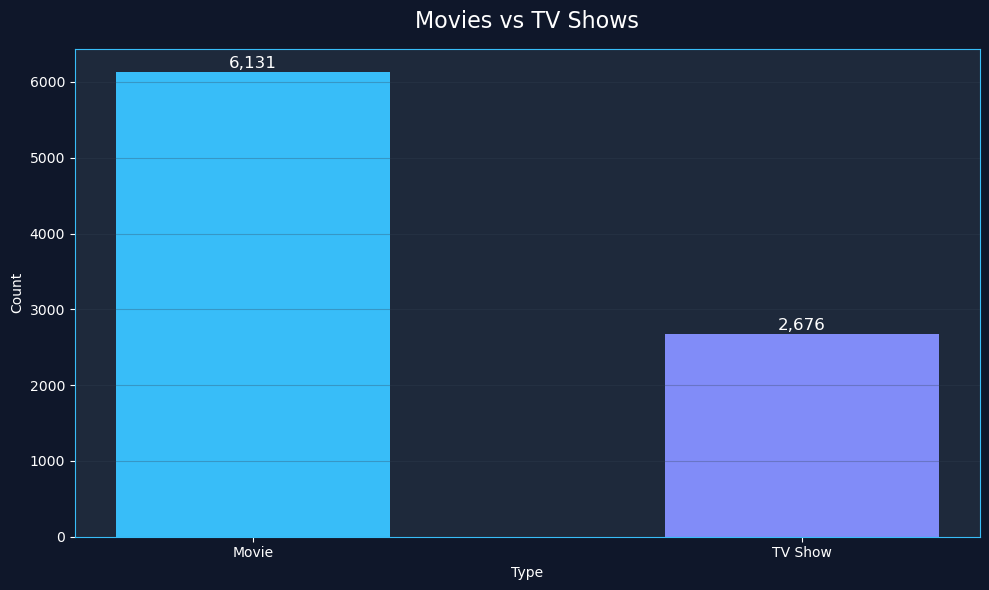

In [11]:
fig,ax=plt.subplots(figsize=(10,6))
counts=df['type'].value_counts()
bars=ax.bar(counts.index,counts.values,color=[ACCENT,ACCENT2],width=0.5)
for bar,val  in zip(bars,counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50, f'{val:,}',ha='center',
            color='white',fontsize=12)
ax.set_title('Movies vs TV Shows',fontsize=16,pad=15)
ax.set_xlabel('Type')
ax.set_ylabel('Count')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('chart1_type.png',dpi=300,
            bbox_inches='tight',facecolor='#0F172A')
plt.show()

##  Top 10 Countries: 

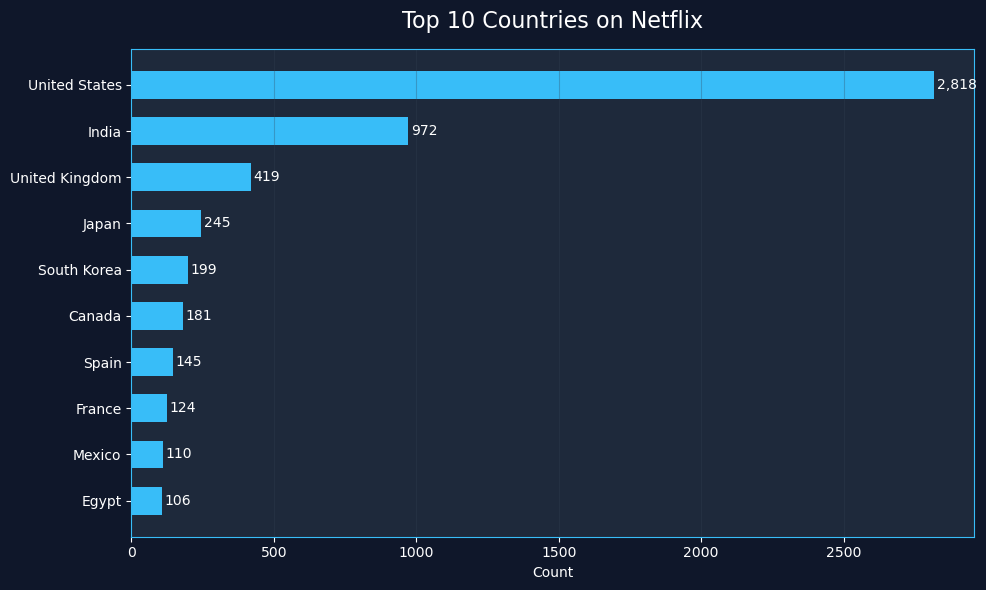

In [12]:
fig,ax=plt.subplots(figsize=(10,6))
top_countries=(df['country'].dropna().value_counts().head(10))
bars = ax.barh(top_countries.index[::-1],
               top_countries.values[::-1],
               color=ACCENT, height=0.6)
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=10)

ax.set_title('Top 10 Countries on Netflix', fontsize=16, pad=15)
ax.set_xlabel('Count')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('chart2_countries.png', dpi=150,
            bbox_inches='tight', facecolor='#0F172A')
plt.show()

#  Content Added Per Year:

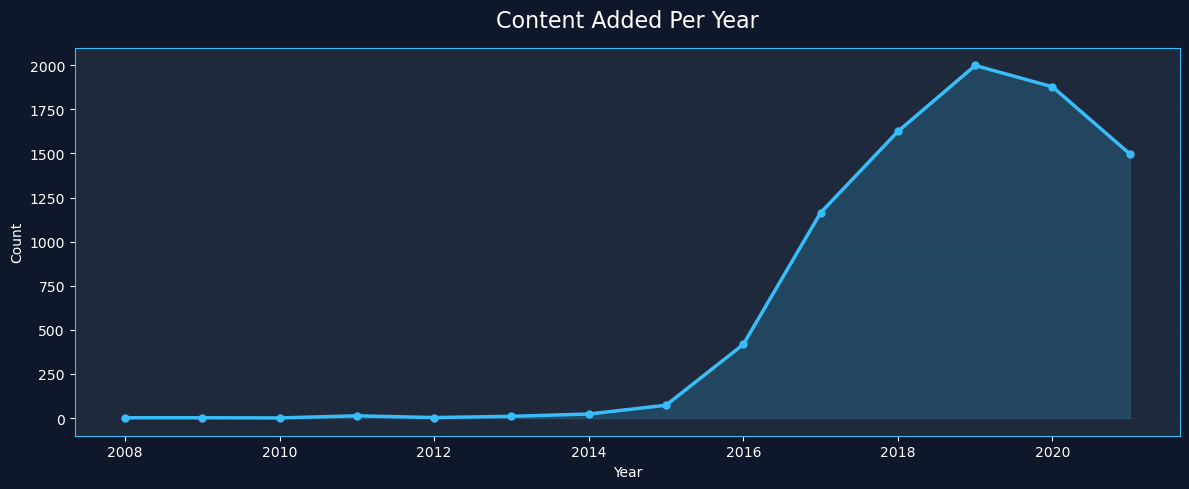

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

yearly = (df['year_added'].dropna()
                          .value_counts()
                          .sort_index())

ax.plot(yearly.index, yearly.values,
        color=ACCENT, linewidth=2.5,
        marker='o', markersize=5)
ax.fill_between(yearly.index, yearly.values,
                alpha=0.2, color=ACCENT)

ax.set_title('Content Added Per Year', fontsize=16, pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('chart3_yearly.png', dpi=300,
            bbox_inches='tight', facecolor='#0F172A')
plt.show()

# Top Ratings:

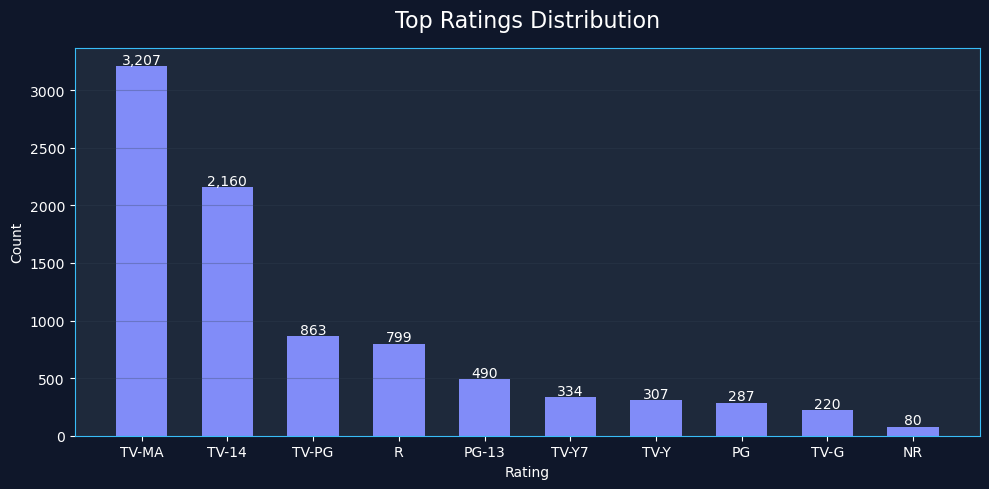

In [15]:
fig,ax=plt.subplots(figsize=(10,5))
ratings=(df['rating'].dropna().value_counts().head(10))
bars=ax.bar(ratings.index,ratings.values,color=ACCENT2,width=0.6)
for bar,val in zip(bars,ratings.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20, f'{val:,}',ha='center',color='white',
            fontsize=10)
ax.set_title('Top Ratings Distribution', fontsize=16, pad=15)
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('chart4_ratings.png', dpi=150,
            bbox_inches='tight', facecolor='#0F172A')
plt.show()    

In [16]:
df.to_csv('netflix_cleaned.csv',index=False)